<a href="https://colab.research.google.com/github/warrensuca/chinese-recipe-api/blob/main/clustering/cluster_recipes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import PowerTransformer
import matplotlib.pyplot as plt
print('setup complete')

setup complete


In [15]:
df_recipes = pd.read_csv('cleaned_recipes.csv')
nutrition_features = ['Calories', 'Carbohydrates', 'Protein', 'Fat', 'Saturated Fat', 'Sodium', 'Sugar']

#Clustering

##Elbow Method
Find the optimal K

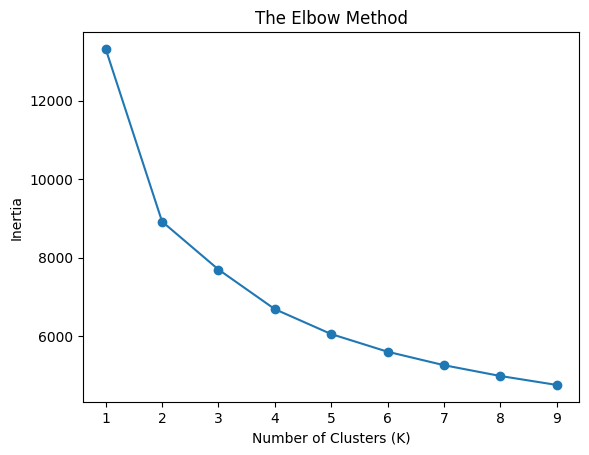

In [16]:
inertia = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=0, n_init='auto')
    kmeans.fit(df_recipes[nutrition_features])
    inertia.append(kmeans.inertia_)

# Plot the Elbow curve
plt.plot(k_range, inertia, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

##Cluster recipes and interpret centroids

In [17]:
df_recipes = pd.read_csv('cleaned_raw_recipes.csv')

kmeans = KMeans(n_clusters=5, random_state=0)

pt = PowerTransformer(method='yeo-johnson')


scaled_features = pt.fit_transform(df_recipes[nutrition_features])


df_recipes['Cluster'] = kmeans.fit_predict(scaled_features)


scaled_centers = kmeans.cluster_centers_


real_world_centers = pt.inverse_transform(scaled_centers)


cluster_profiles = pd.DataFrame(real_world_centers, columns=nutrition_features)
cluster_profiles.index = [f"Cluster {i}" for i in range(5)]


display(cluster_profiles.round(1))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


,Calories,Carbohydrates,Protein,Fat,Saturated Fat,Sodium,Sugar
Cluster 0,103.9,9.4,3.7,4.1,0.9,0.3,1.7
Cluster 1,540.1,34.7,23.9,30.4,9.7,0.8,5.2
Cluster 2,269.1,32.7,5.0,11.6,4.2,0.2,13.3
Cluster 3,331.0,32.7,18.3,11.8,2.1,0.8,4.7
Cluster 4,277.8,7.8,19.0,16.7,4.4,0.6,2.0


##Seem to be distinct archetypes
- sides
- protein/meat heavy mains
- sweets
- balanced meals
- keto friendly

In [18]:
cluster_names = {
    0: "Light Sides & Soups",
    1: "Rich Meat Mains",
    2: "Desserts & Sweets",
    3: "Balanced Carb-Mains",
    4: "Low-Carb Proteins"
}


df_recipes['Cluster_Name'] = df_recipes['Cluster'].map(cluster_names)


In [19]:
output_file = "clustered_recipes.csv"

df_recipes.to_csv(
    output_file,
    index=False,
    encoding="utf-8"
)

print(f"Output file: {output_file}")

Output file: clustered_recipes.csv
